In [2]:
import numpy as np
import matplotlib.pyplot as pl
from scipy import integrate
import matplotlib
from scipy.special import gamma

red = '#D60606'
blue = '#0083DE'
green = '#00BA75'
yellow = '#FFC61E'
purple = '#A433B3'
orange = '#FD882E'
color_arr = [red, blue, green, yellow, purple, orange]

mplparams = {
    'text.usetex': True,
    'lines.linewidth': 1.5,
    'lines.markersize': 10,
    'axes.grid': False,
    'axes.labelweight': 'normal',
    'font.family': 'DejaVu Sans',
    'font.size': 36,
    'figure.figsize': (15, 10),
    'legend.fontsize': 26,
    'legend.handlelength': 2,
    'legend.numpoints': 1,
    'axes.grid': True,
    'grid.alpha': 0.9,
    'axes.prop_cycle': matplotlib.cycler(color=color_arr)
}
matplotlib.rcParams.update(mplparams)

In [3]:
def f_calc(t, beta, f0):
    return f0*(1-8/3*beta*t)**(-3/8)

def naive_fft(signal, time):
    fft_freq = np.fft.fftshift(np.fft.fftfreq(len(signal), np.diff(time)[0]))
    fft_amp = np.fft.fftshift(np.fft.fft(signal))/len(signal)
    fft_power = abs(fft_amp)**2
    return fft_freq, fft_amp, fft_power

In [4]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)
day = 86400

In [5]:
n_days = 3
duration = n_days*day
f_signal = 20
# very approximately 1st Jan 2024
t_offset = np.arange(0, duration, 1/f_signal)
samp_freq = 1/(np.diff(t_offset)[0])
print(f"Sampling frequency = {samp_freq}")

f0 = 1
Mc = 1.3*1e0 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
f_source = f_calc(t_offset, beta, f0)
phi_source = 2*np.pi * \
    integrate.cumulative_trapezoid(f_source, x=t_offset, initial=0)
signal_source = np.exp(1j*phi_source)

Sampling frequency = 20.0


In [6]:
fft_freq, fft_amp, fft_power = naive_fft(signal_source, t_offset)

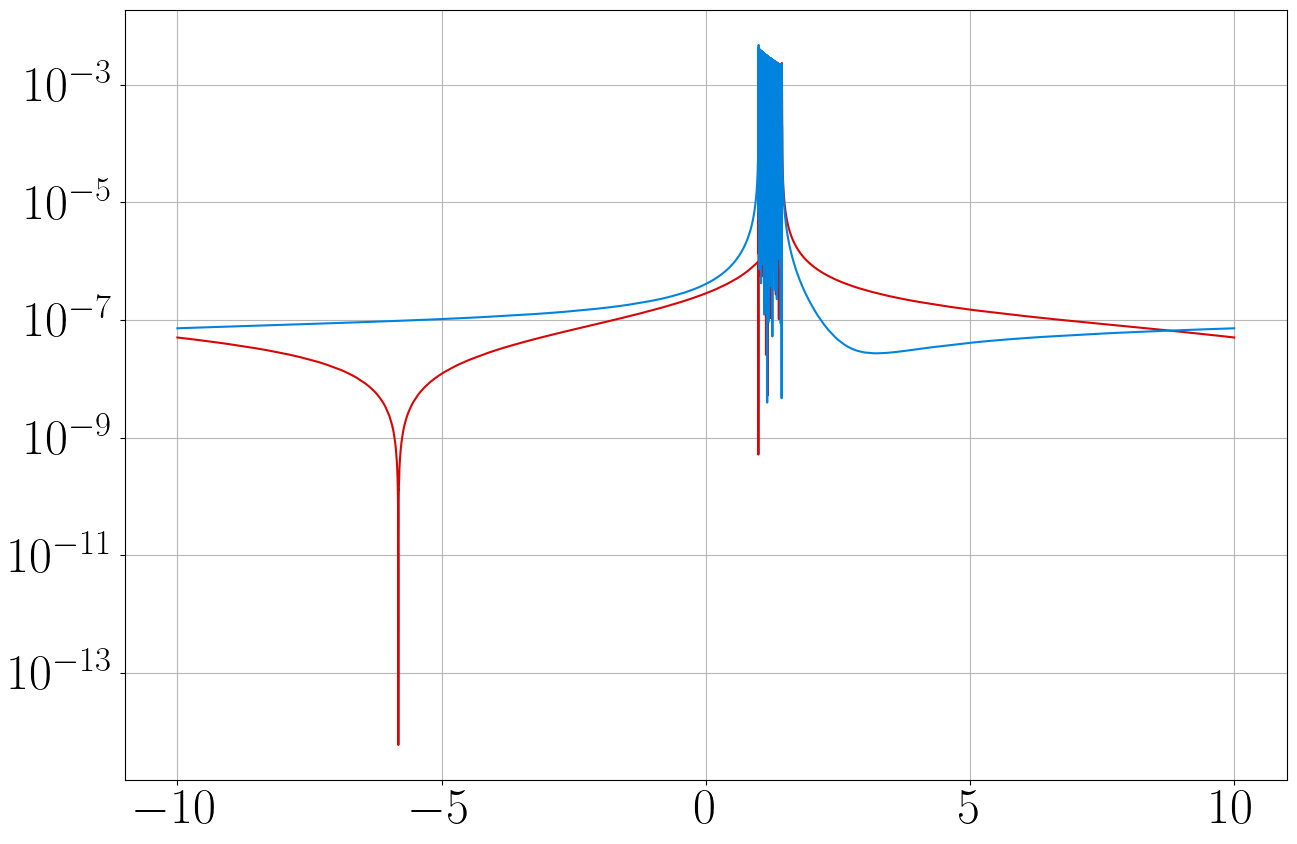

In [57]:
pl.semilogy(fft_freq, abs(np.real(fft_amp)))
pl.semilogy(fft_freq, abs(np.imag(fft_amp)))

<BarContainer object of 30 artists>

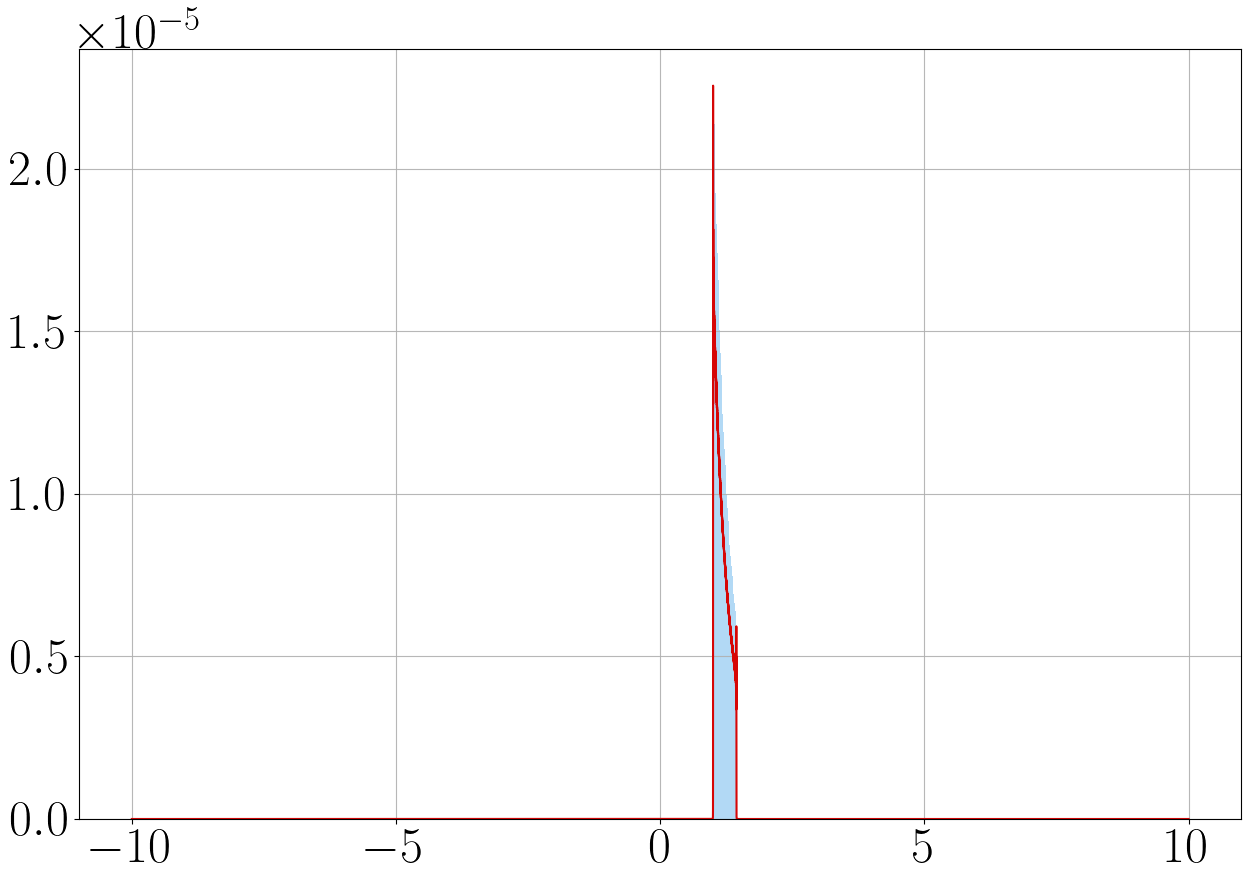

In [43]:
pl.plot(fft_freq, fft_power, color=red)
counts, bins = np.histogram(f_source, bins=30)
normalization = max(fft_power) / max(counts)
normalized_counts = normalization * counts
pl.bar(bins[:-1], normalized_counts, width=np.diff(bins), align='edge', alpha=0.3, color=blue)

In [58]:
def template_calc(omega, beta):
    temp0 = (1+1j)/5*(-1)**(15/16)*6**(3/8)*np.exp(3j*abs(omega)/(8*beta))
    temp1 = np.pi**(3/2)*(omega+abs(omega))/np.cos(np.pi/8)*((2+1j)+np.tan(np.pi/8))
    temp2 = beta**(3/8)*abs(omega)**(21/8)*gamma(-5/8)
    return temp0*temp1/temp2

In [59]:
signal_template = template_calc(2*np.pi*fft_freq, beta)

/tmp/ipykernel_72952/2136539973.py:5: RuntimeWarning: invalid value encountered in divide
  return temp0*temp1/temp2


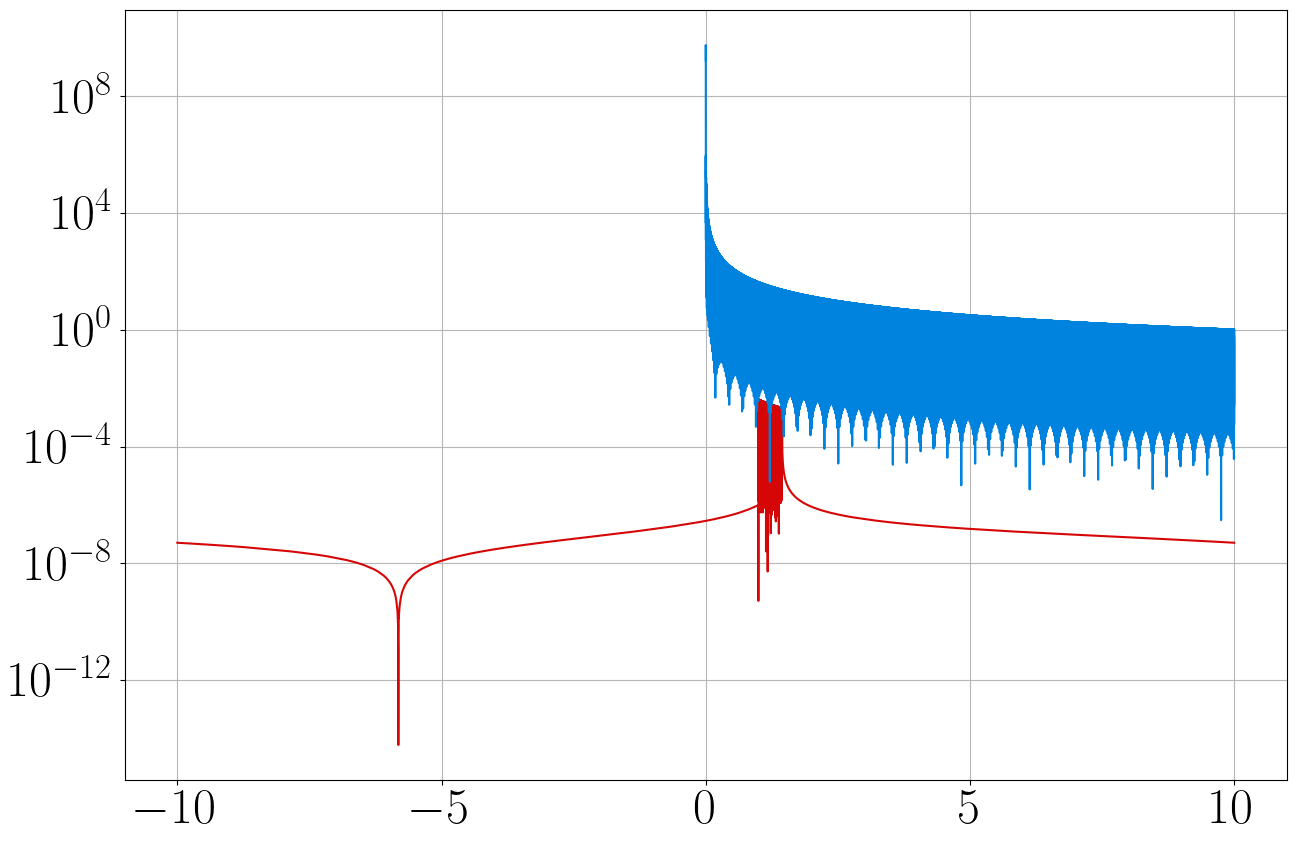

In [60]:
pl.semilogy(fft_freq, abs(np.real(fft_amp)))
pl.semilogy(fft_freq, abs(np.real(signal_template)))

In [63]:
template_calc(2*np.pi*-2, beta)

(-0-0j)

In [62]:
beta**(3/8)*abs(-1)**(21/8)*gamma(-5/8)

-0.020519686444909632